In [4]:
import os, time, joblib, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.exceptions import UndefinedMetricWarning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, roc_auc_score, RocCurveDisplay
)

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

# Répertoires
ROOT        = os.getcwd()
OUTPUT_DIR = os.path.abspath(os.path.join(ROOT, "..", "TP2", "/Users/fareselkolli/Desktop/tp2 inf 5082/tp2/outputs"))
RESULTS_CSV = os.path.join(OUTPUT_DIR, "results_classical.csv")
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [5]:
def build_model(name: str, n_train: int):
    if name == "SVM":
        return Pipeline([("scaler", StandardScaler()),
                         ("clf", SVC(kernel="rbf", C=10, probability=True))])
    if name == "kNN":
        k = min(7, max(1, n_train - 1))
        return Pipeline([("scaler", StandardScaler()),
                         ("clf", KNeighborsClassifier(n_neighbors=k))])
    if name == "Tree":
        return DecisionTreeClassifier()
    if name == "NB":
        return GaussianNB()
    raise ValueError(name)

def safe_numeric(df: pd.DataFrame) -> pd.DataFrame:
    return df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

def save_cm_png(cm: np.ndarray, labels: list, title: str, path: str):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path)
    plt.close()


🔍 Recherche des fichiers de features...

📂 Covid19-XRAYS_inceptionv3.csv


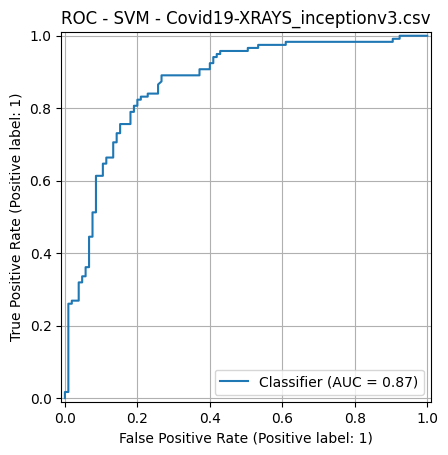

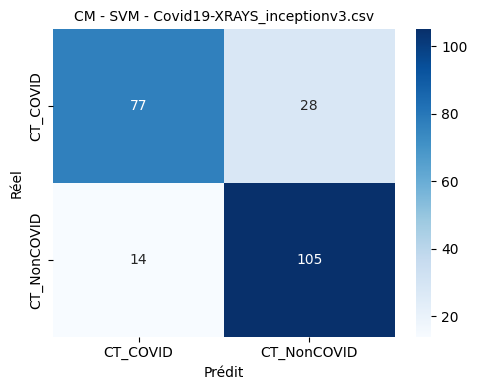

 SVM - Accuracy: 0.81 | F1: 0.81


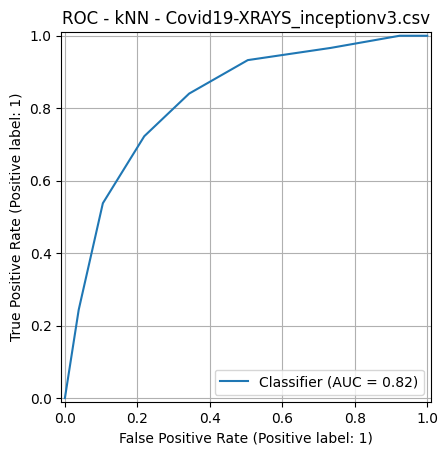

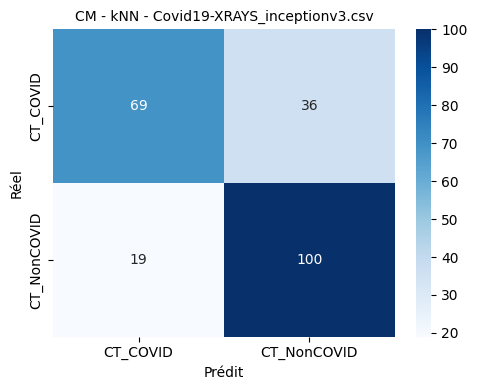

 kNN - Accuracy: 0.75 | F1: 0.75


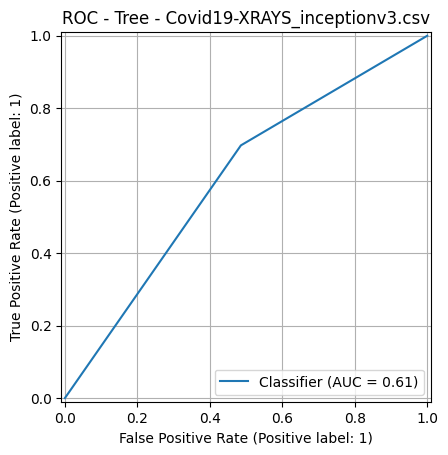

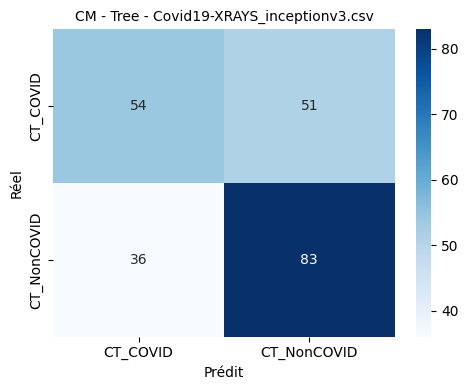

 Tree - Accuracy: 0.61 | F1: 0.61


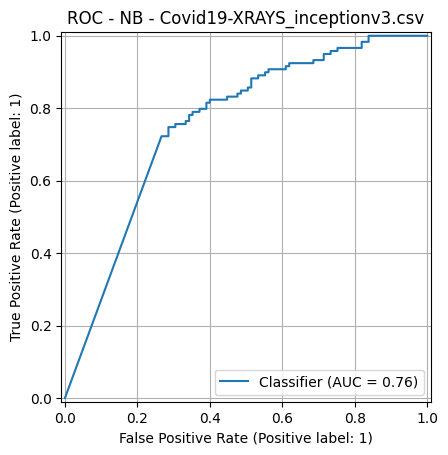

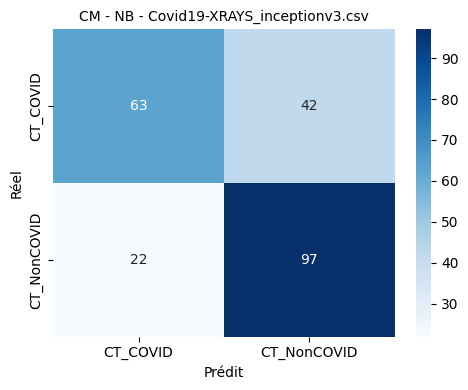

 NB - Accuracy: 0.71 | F1: 0.71

📂 Covid19-XRAYS_resnet50.csv


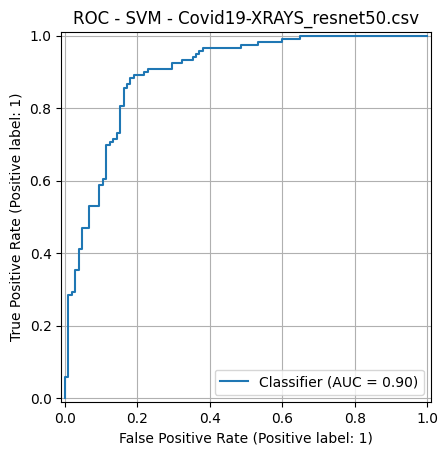

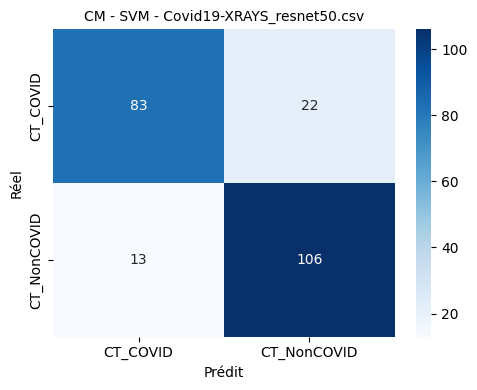

 SVM - Accuracy: 0.84 | F1: 0.84


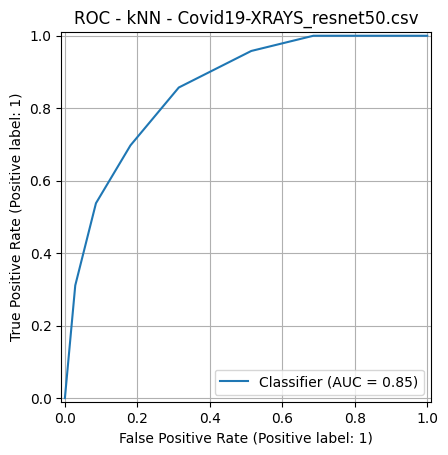

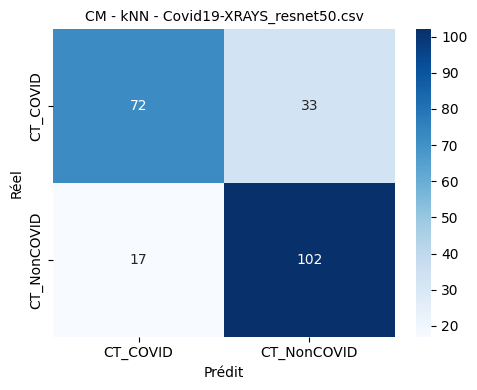

 kNN - Accuracy: 0.78 | F1: 0.77


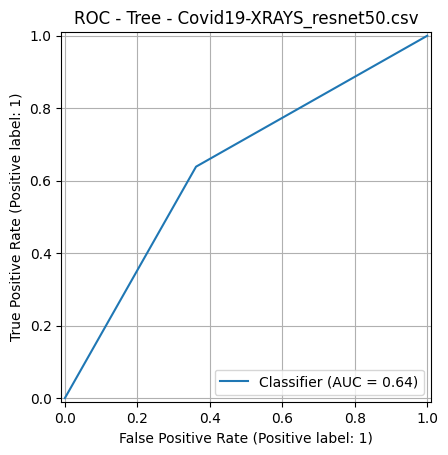

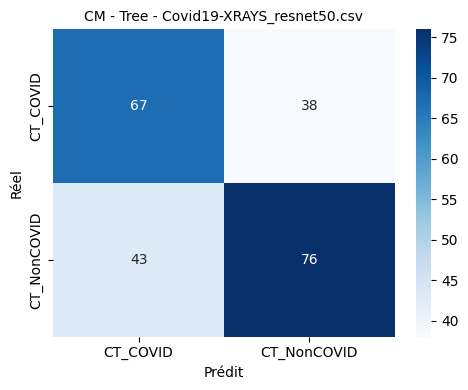

 Tree - Accuracy: 0.64 | F1: 0.64


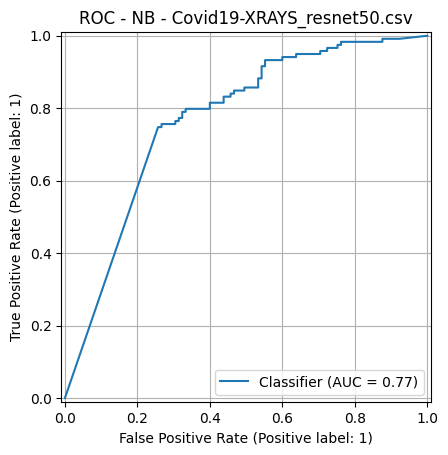

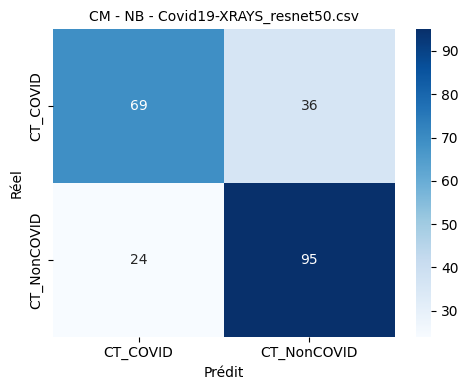

 NB - Accuracy: 0.73 | F1: 0.73

📂 Covid19-XRAYS_vgg16.csv


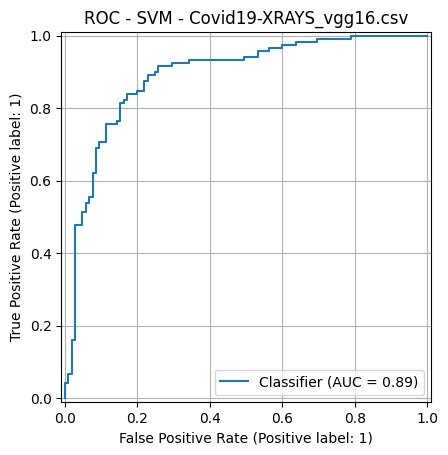

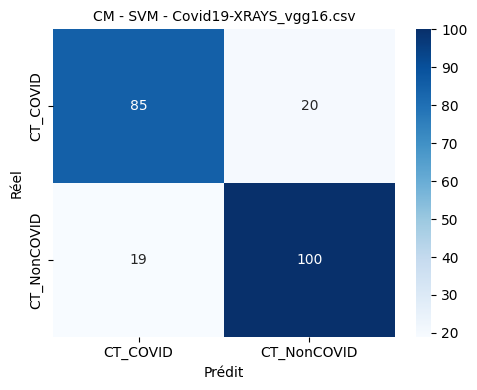

 SVM - Accuracy: 0.83 | F1: 0.83


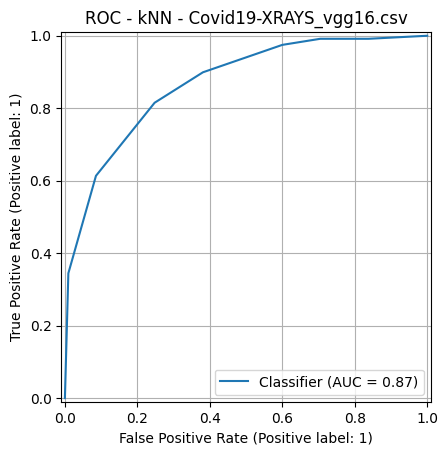

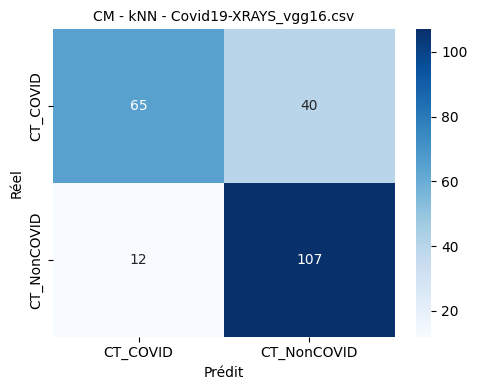

 kNN - Accuracy: 0.77 | F1: 0.76


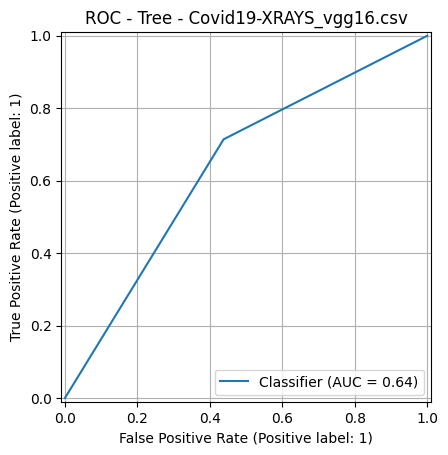

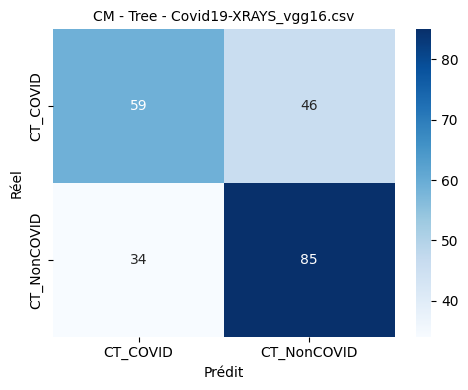

 Tree - Accuracy: 0.64 | F1: 0.64


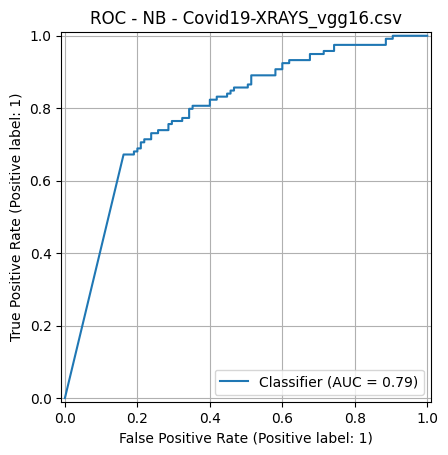

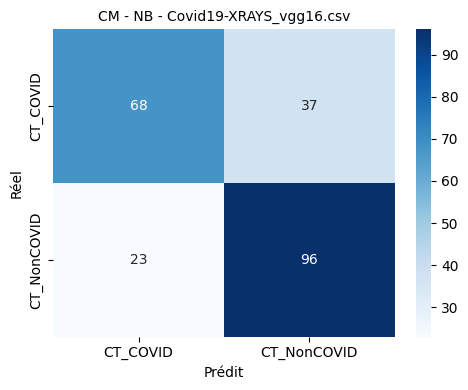

 NB - Accuracy: 0.73 | F1: 0.73

📂 DTD_inceptionv3.csv


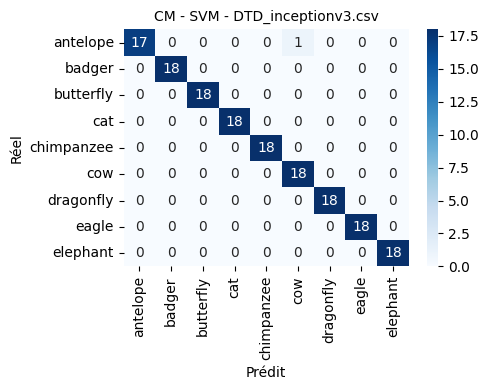

 SVM - Accuracy: 0.99 | F1: 0.99


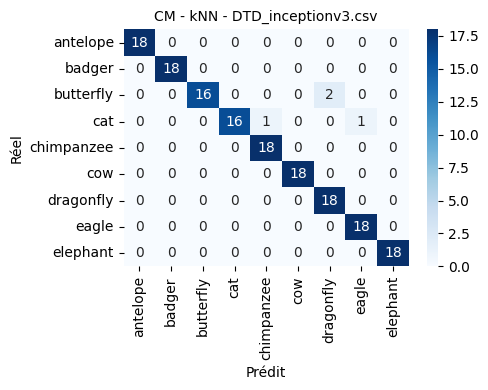

 kNN - Accuracy: 0.98 | F1: 0.98


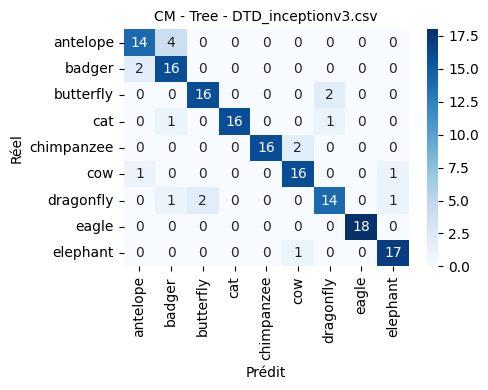

 Tree - Accuracy: 0.88 | F1: 0.88


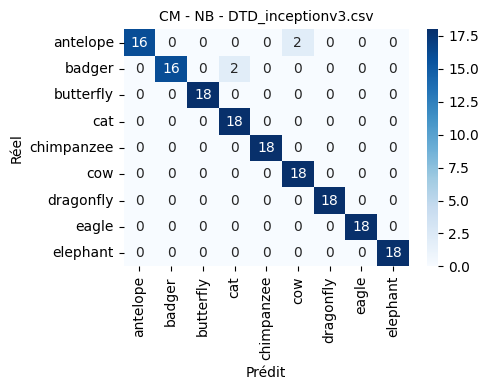

 NB - Accuracy: 0.98 | F1: 0.98

📂 DTD_resnet50.csv


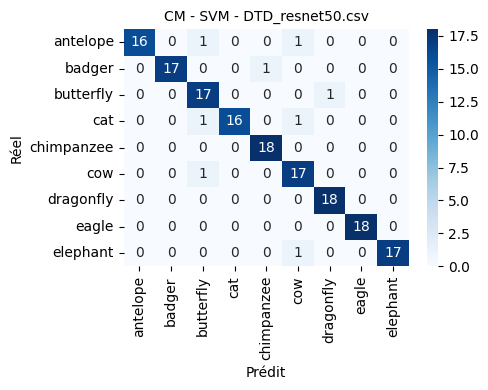

 SVM - Accuracy: 0.95 | F1: 0.95


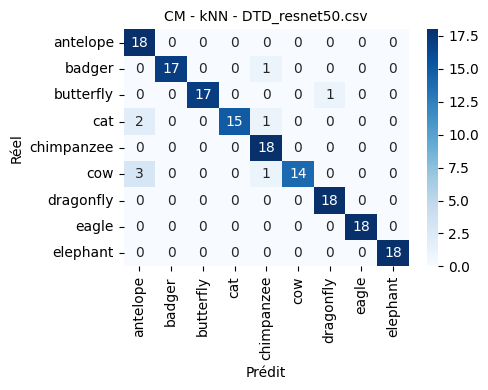

 kNN - Accuracy: 0.94 | F1: 0.94


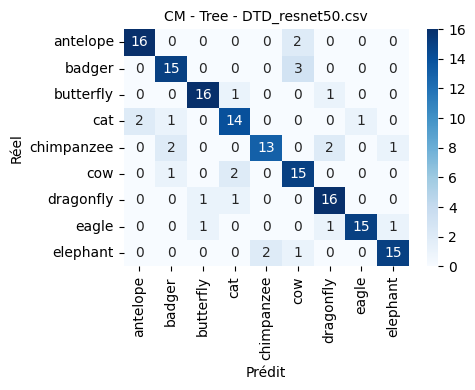

 Tree - Accuracy: 0.83 | F1: 0.83


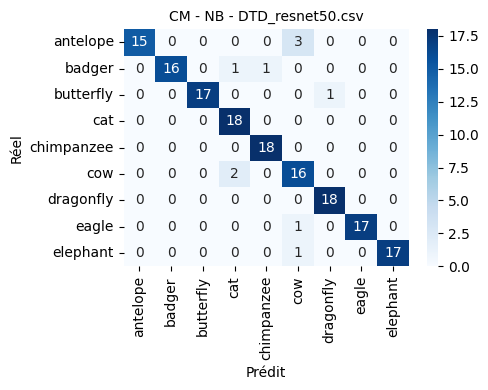

 NB - Accuracy: 0.94 | F1: 0.94

📂 DTD_vgg16.csv


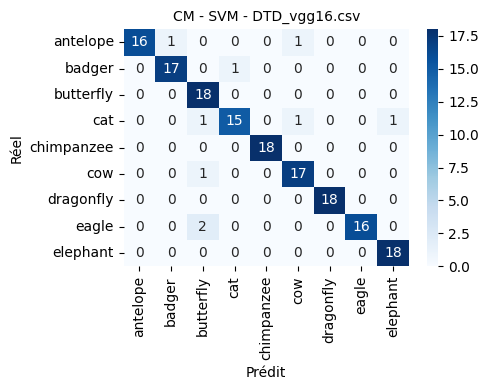

 SVM - Accuracy: 0.94 | F1: 0.94


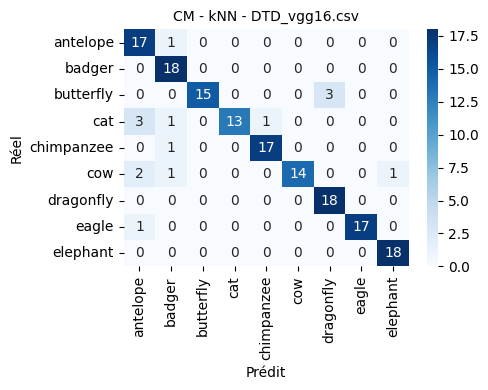

 kNN - Accuracy: 0.91 | F1: 0.91


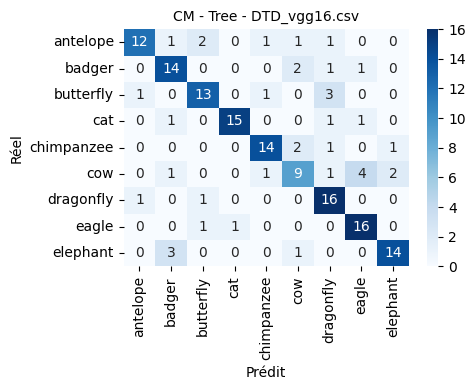

 Tree - Accuracy: 0.76 | F1: 0.76


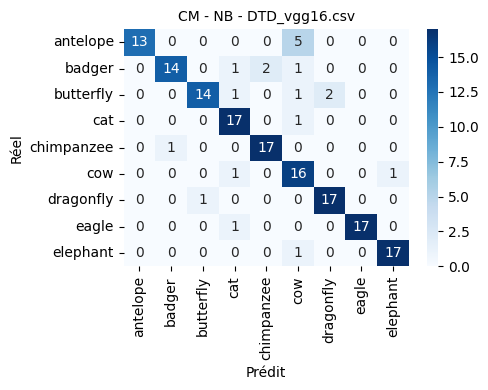

 NB - Accuracy: 0.88 | F1: 0.88

📂 Iris_inceptionv3.csv


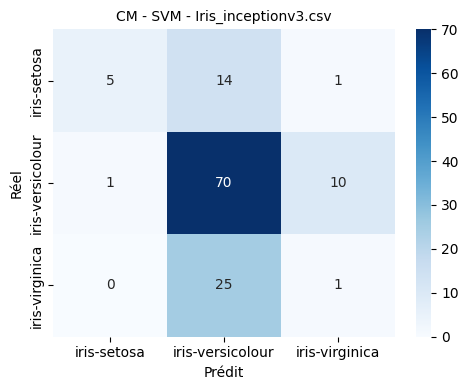

 SVM - Accuracy: 0.60 | F1: 0.54


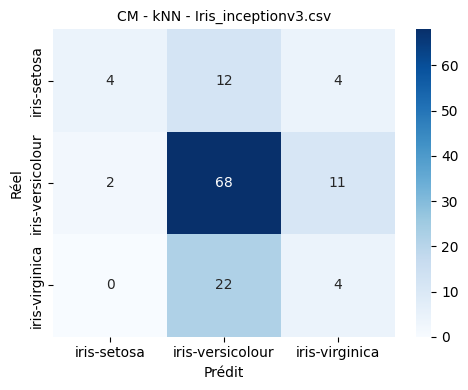

 kNN - Accuracy: 0.60 | F1: 0.56


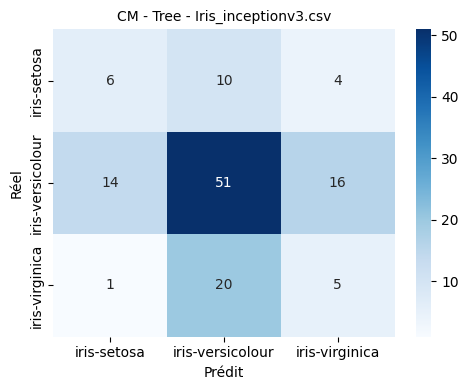

 Tree - Accuracy: 0.49 | F1: 0.49


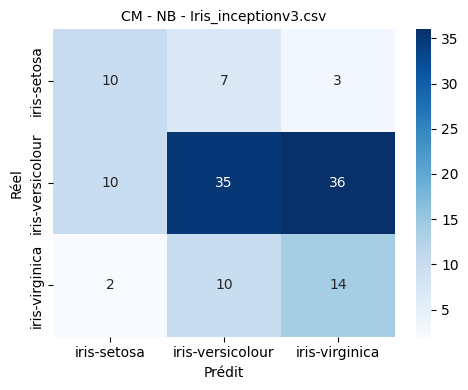

 NB - Accuracy: 0.46 | F1: 0.48

📂 Iris_resnet50.csv


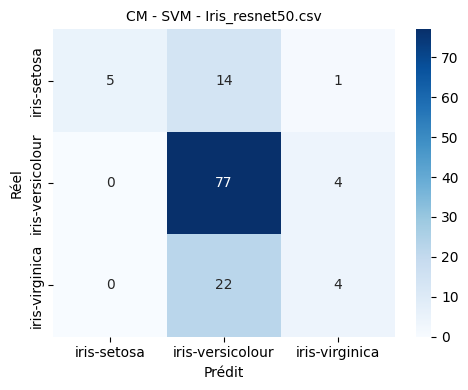

 SVM - Accuracy: 0.68 | F1: 0.62


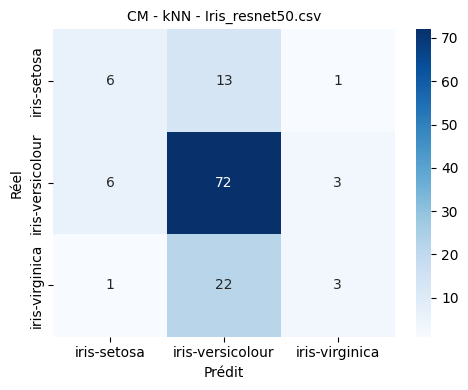

 kNN - Accuracy: 0.64 | F1: 0.58


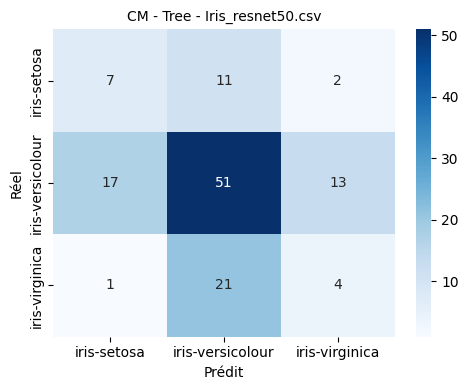

 Tree - Accuracy: 0.49 | F1: 0.48


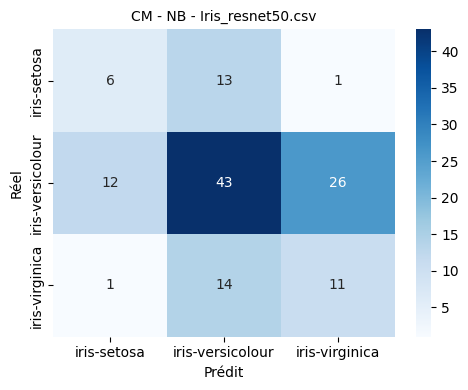

 NB - Accuracy: 0.47 | F1: 0.48

📂 Iris_vgg16.csv


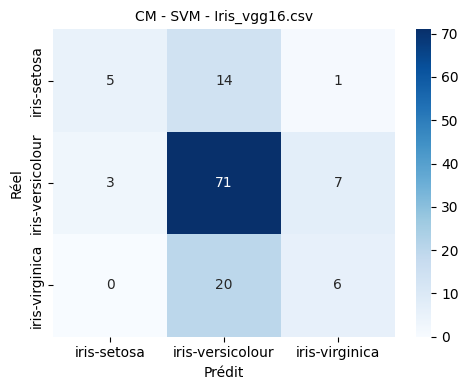

 SVM - Accuracy: 0.65 | F1: 0.60


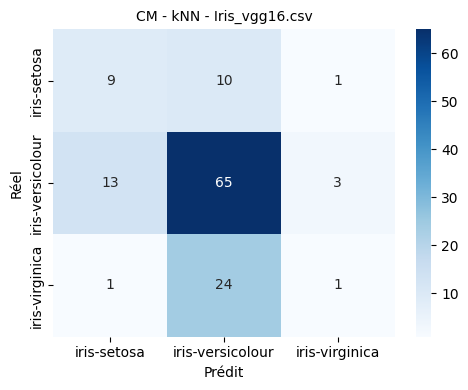

 kNN - Accuracy: 0.59 | F1: 0.54


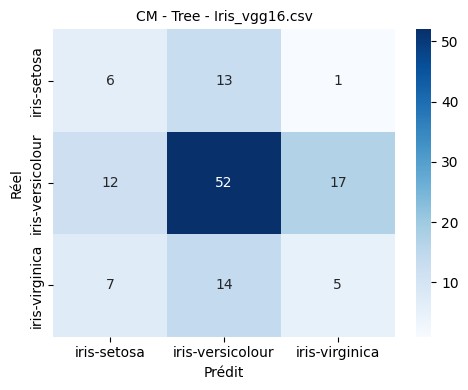

 Tree - Accuracy: 0.50 | F1: 0.50


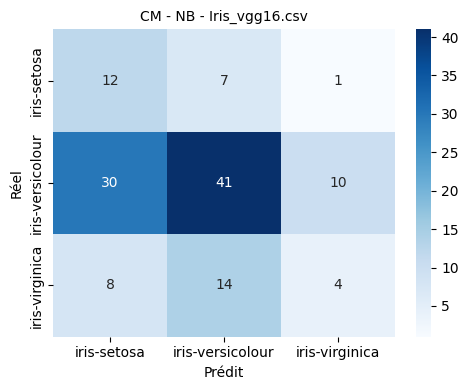

 NB - Accuracy: 0.45 | F1: 0.46

📂 Wildfire_inceptionv3.csv


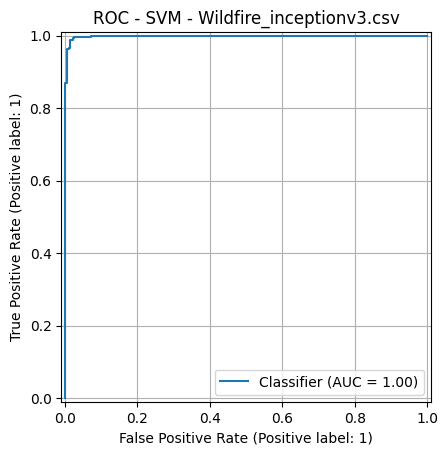

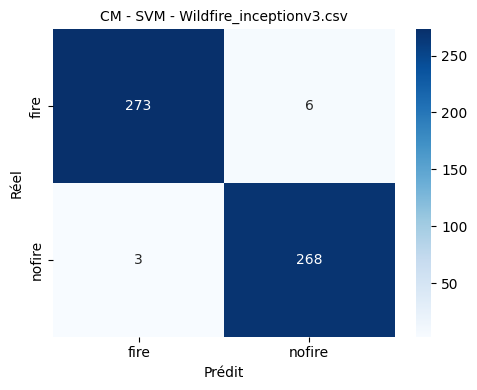

 SVM - Accuracy: 0.98 | F1: 0.98


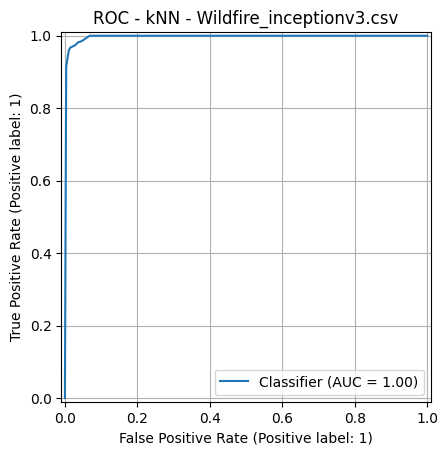

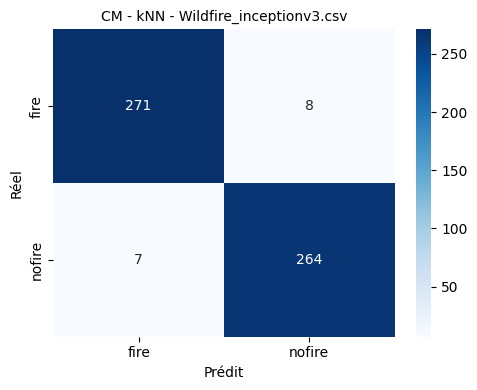

 kNN - Accuracy: 0.97 | F1: 0.97


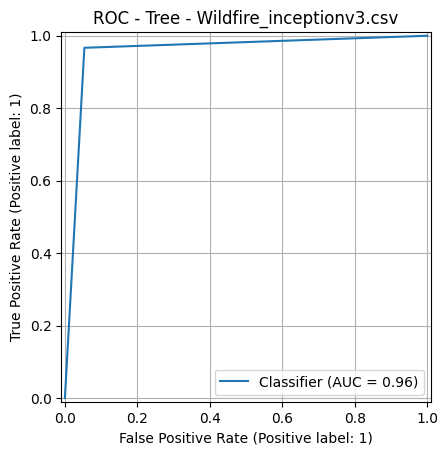

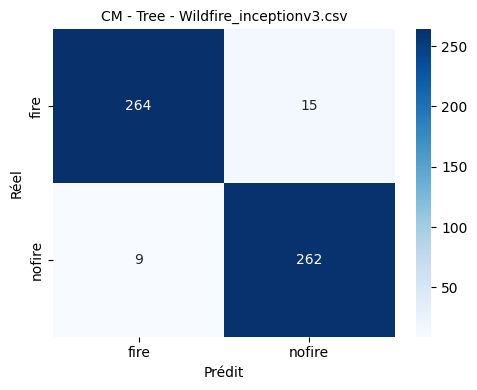

 Tree - Accuracy: 0.96 | F1: 0.96


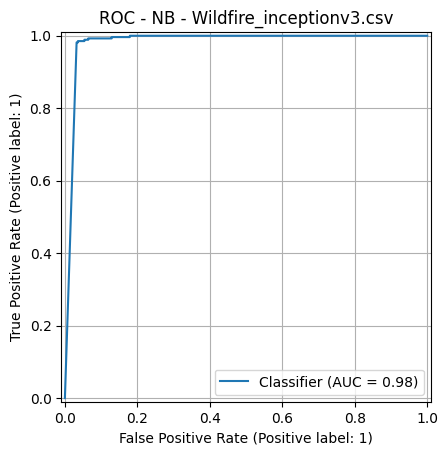

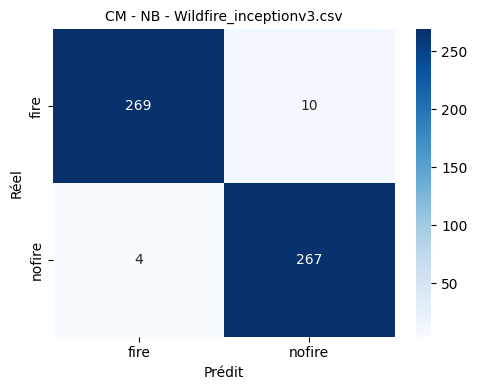

 NB - Accuracy: 0.97 | F1: 0.97

📂 Wildfire_resnet50.csv


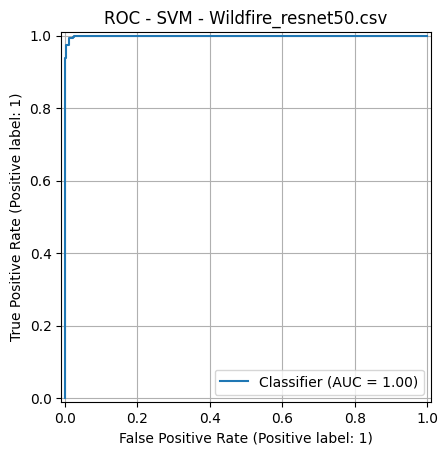

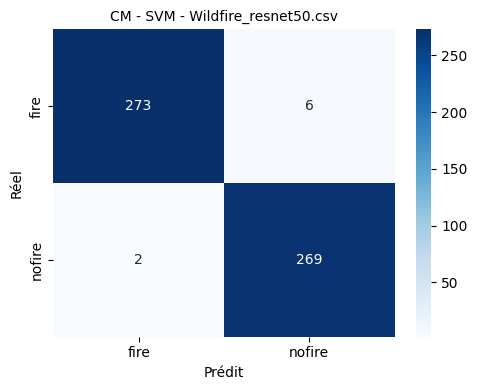

 SVM - Accuracy: 0.99 | F1: 0.99


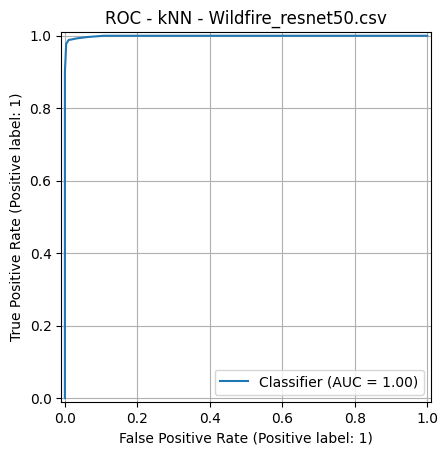

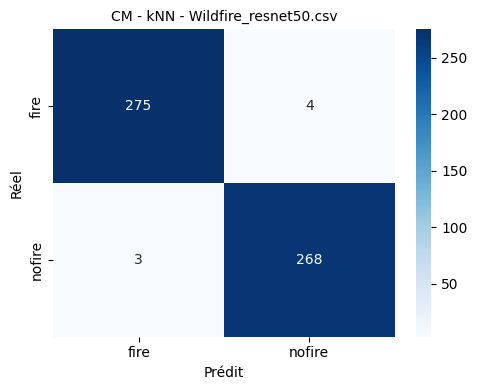

 kNN - Accuracy: 0.99 | F1: 0.99


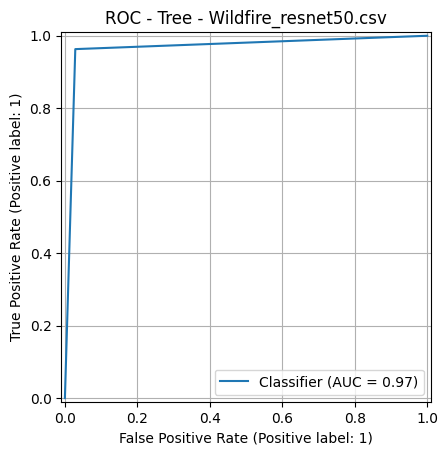

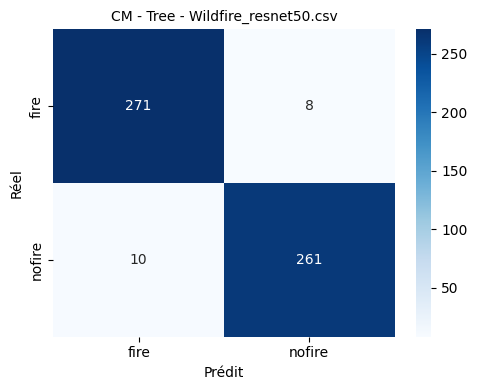

 Tree - Accuracy: 0.97 | F1: 0.97


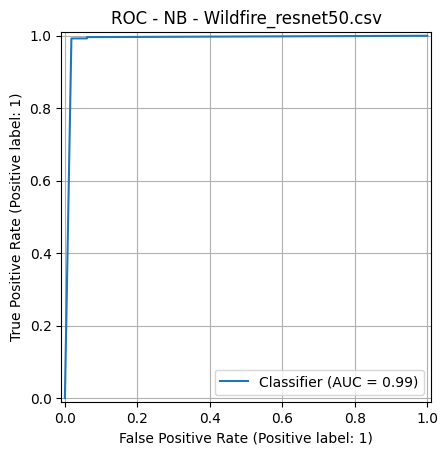

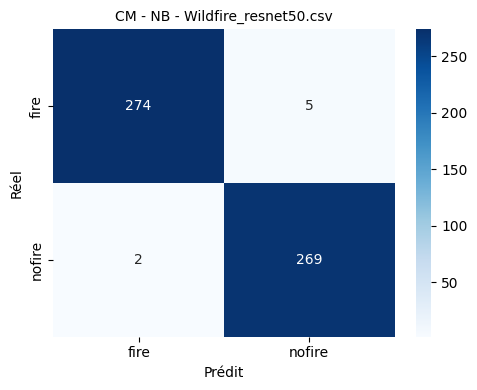

 NB - Accuracy: 0.99 | F1: 0.99

📂 Wildfire_vgg16.csv


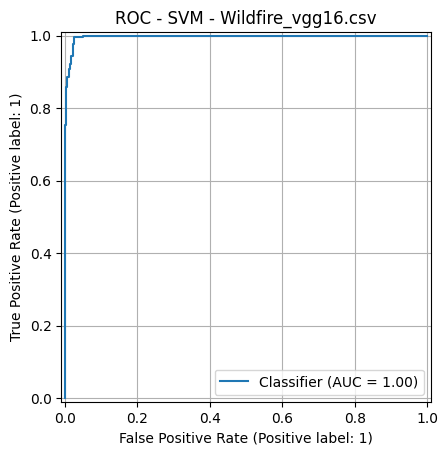

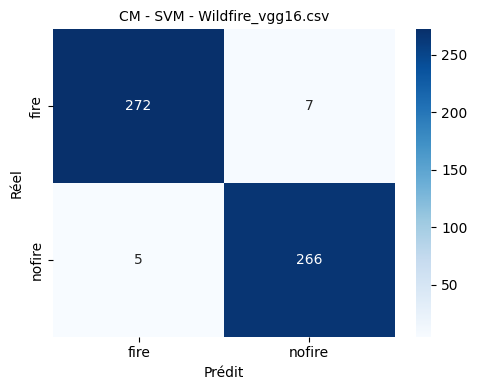

 SVM - Accuracy: 0.98 | F1: 0.98


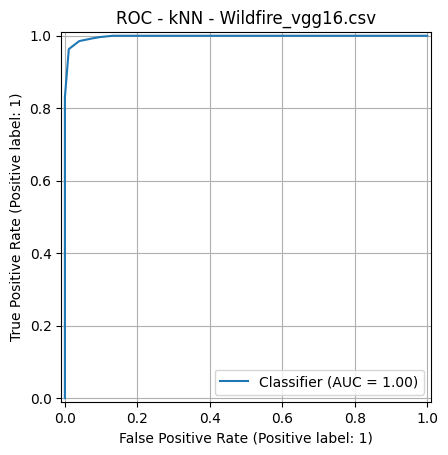

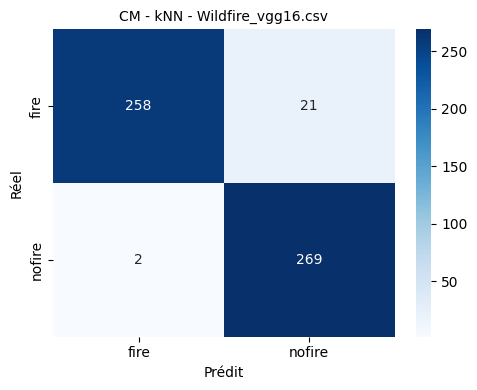

 kNN - Accuracy: 0.96 | F1: 0.96


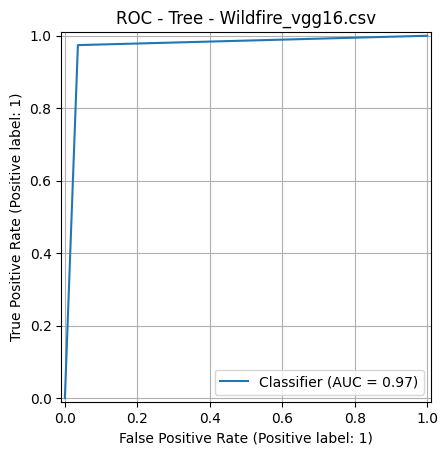

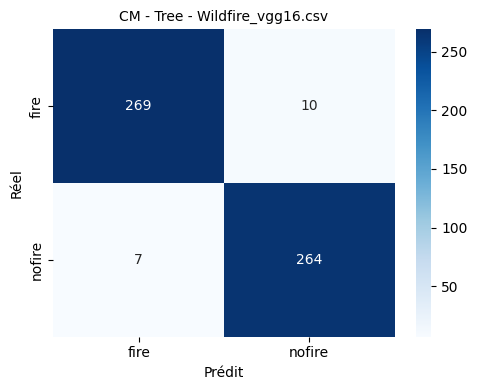

 Tree - Accuracy: 0.97 | F1: 0.97


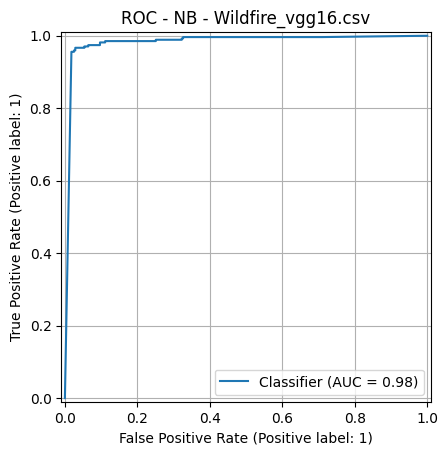

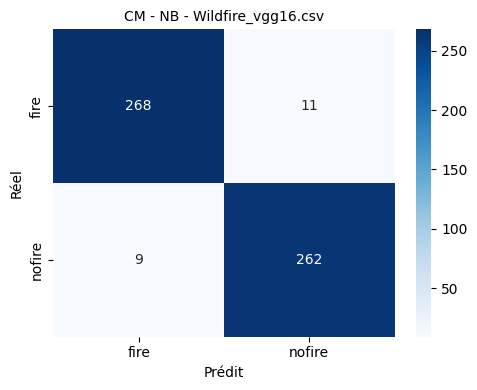

 NB - Accuracy: 0.96 | F1: 0.96


In [ ]:
rows = []

print("Recherche des fichiers de features...")
for csv_file in sorted(os.listdir(OUTPUT_DIR)):
    if not csv_file.endswith(".csv"): continue
    if csv_file.startswith("cm_") or "results_classical.csv" in csv_file:
        continue
    if all(k not in csv_file for k in ("_vgg16", "_resnet50", "_inceptionv3")):
        continue

    print(f"\n {csv_file}")
    df = pd.read_csv(os.path.join(OUTPUT_DIR, csv_file), engine="python")

    if "label" in df.columns:
        X_df, y = df.drop("label", axis=1), df["label"].values
    else:
        X_df, y = df.iloc[:, :-1], df.iloc[:, -1].values
    X = safe_numeric(X_df).values

    strat_ok = pd.Series(y).value_counts().min() >= 2
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.30,
        stratify=y if strat_ok else None,
        random_state=42
    )

    for name in ["SVM", "kNN", "Tree", "NB"]:
        if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
            rows.append([csv_file, name] + [np.nan]*6)
            continue

        model = build_model(name, len(X_tr))
        t0 = time.time()
        model.fit(X_tr, y_tr)
        train_time = time.time() - t0

        y_pred = model.predict(X_te)

        acc  = accuracy_score(y_te, y_pred)
        f1   = f1_score(y_te, y_pred, average="weighted")
        prec = precision_score(y_te, y_pred, average="weighted")
        rec  = recall_score(y_te, y_pred, average="weighted")

        # ROC-AUC
        try:
            y_prob = model.predict_proba(X_te)
            if y_prob.shape[1] == 2:
                lb = LabelBinarizer().fit(y_te)
                ybin = lb.transform(y_te).ravel()
                auc = roc_auc_score(ybin, y_prob[:, 1])
                RocCurveDisplay.from_predictions(ybin, y_prob[:, 1])
                plt.title(f"ROC - {name} - {csv_file}")
                plt.grid(True)
                plt.show()
            else:
                auc = roc_auc_score(y_te, y_prob, multi_class="ovr", average="macro")
        except:
            auc = np.nan

        # Matrice de confusion
        unique_labels = sorted(np.unique(np.concatenate([y_te, y_pred])))
        cm = confusion_matrix(y_te, y_pred, labels=unique_labels)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
        plt.title(f"CM - {name} - {csv_file}", fontsize=10)
        plt.xlabel("Prédit")
        plt.ylabel("Réel")
        plt.tight_layout()
        plt.show()
        
        # Sauvegarde modèle
        joblib.dump(model, os.path.join(OUTPUT_DIR, csv_file.replace(".csv", f"_{name}.joblib")))

        rows.append([csv_file, name, acc, f1, prec, rec, auc, train_time])
        print(f" {name} - Accuracy: {acc:.2f} | F1: {f1:.2f}")


In [14]:
# Création du DataFrame à partir de rows
df_results = pd.DataFrame(
    rows,
    columns=[
        "features_csv", "model", "accuracy", "f1",
        "precision", "recall", "auc", "train_time"
    ]
)

# Tri décroissant sur accuracy et remise à zéro de l’index
df_results_sorted = (
    df_results
    .sort_values(by="accuracy", ascending=False)
    .reset_index(drop=True)      
)

# Sauvegarde du classement 
df_results_sorted.to_csv(RESULTS_CSV, index=False)

# Affichage du tableau trié
display(df_results_sorted)

,features_csv,model,accuracy,f1,precision,recall,auc,train_time
0,DTD_inceptionv3.csv,SVM,0.993827,0.993822,0.994152,0.993827,1.000000,0.725274
1,Wildfire_resnet50.csv,kNN,0.987273,0.987273,0.987280,0.987273,0.999213,0.027632
2,Wildfire_resnet50.csv,NB,0.987273,0.987273,0.987333,0.987273,0.988857,0.036649
3,Wildfire_resnet50.csv,SVM,0.985455,0.985455,0.985560,0.985455,0.999497,2.594303
4,Wildfire_inceptionv3.csv,SVM,0.983636,0.983637,0.983697,0.983636,0.998545,2.083611
5,Wildfire_vgg16.csv,SVM,0.978182,0.978183,0.978209,0.978182,0.997223,0.637968
6,DTD_inceptionv3.csv,NB,0.975309,0.975232,0.977778,0.975309,0.995370,0.006844
7,DTD_inceptionv3.csv,kNN,0.975309,0.975074,0.977193,0.975309,1.000000,0.007641
8,Wildfire_inceptionv3.csv,NB,0.974545,0.974546,0.974779,0.974545,0.982462,0.018780
9,Wildfire_inceptionv3.csv,kNN,0.972727,0.972728,0.972735,0.972727,0.996555,0.024139


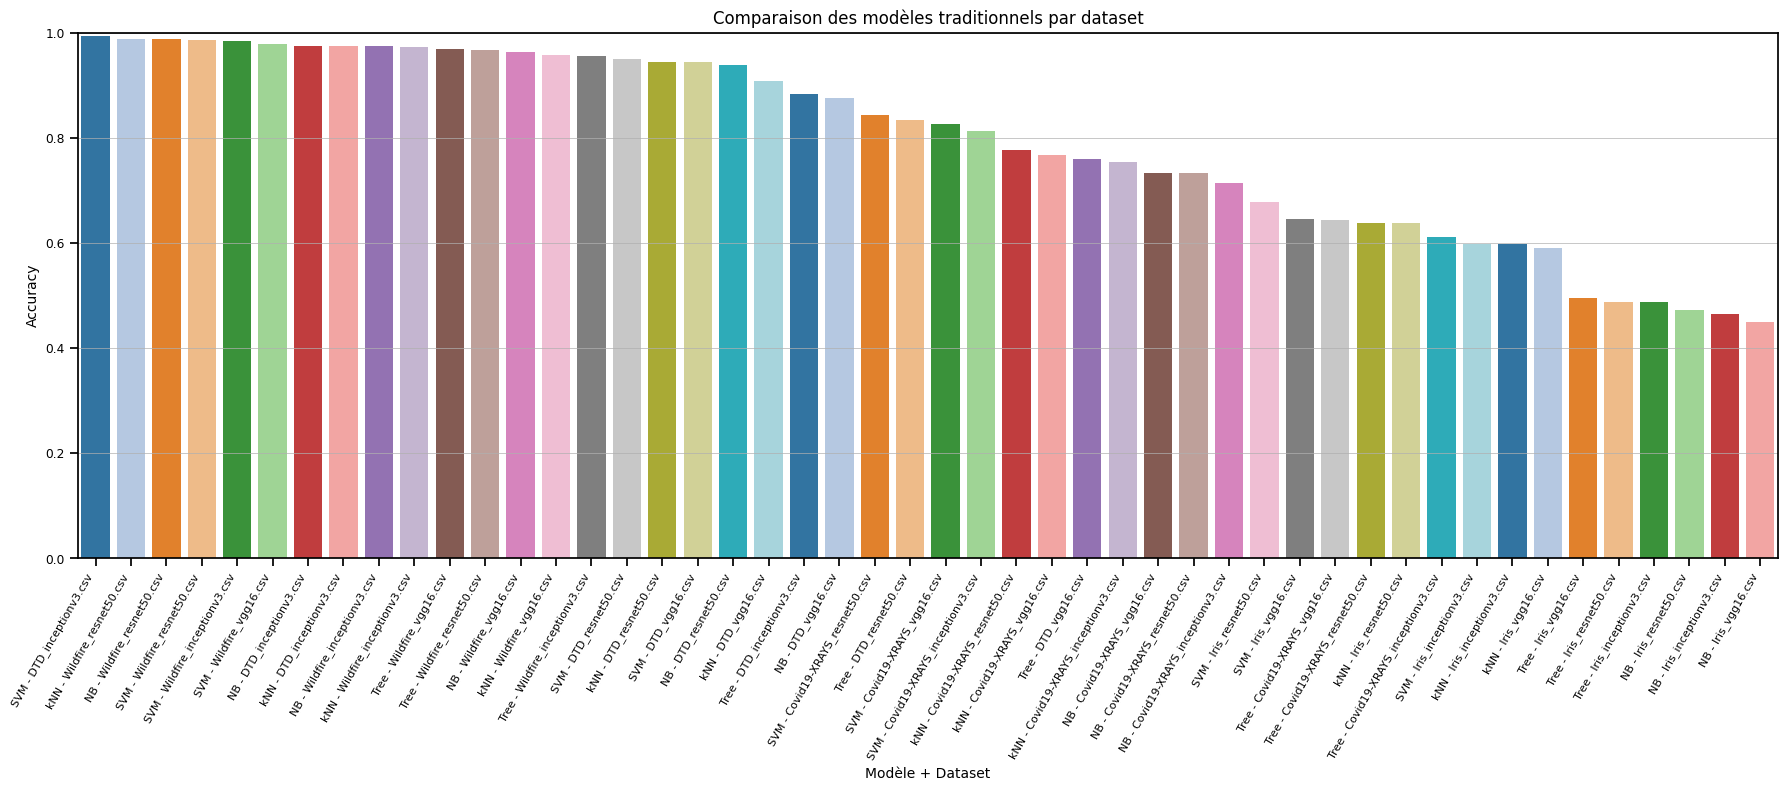

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Trier par accuracy
df_results_sorted = df_results.sort_values(by="accuracy", ascending=False)
df_results_sorted["label"] = df_results_sorted["model"] + " - " + df_results_sorted["features_csv"]

sns.set_context("notebook", font_scale=0.8)

plt.figure(figsize=(18, 8))

# On met label à la fois sur x et hue, puis legend=False pour éviter le bloc légende
sns.barplot(
    data=df_results_sorted,
    x="label",
    y="accuracy",
    hue="label",          
    dodge=False,          
    palette="tab20",
    legend=False          
)

plt.title("Comparaison des modèles traditionnels par dataset", fontsize=12)
plt.ylabel("Accuracy", fontsize=10)
plt.xlabel("Modèle + Dataset", fontsize=10)
plt.ylim(0, 1)
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.grid(True, axis='y', linewidth=0.5)
plt.tight_layout()
plt.show()
